In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g23_c05.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g18_c05.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g10_c01.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g18_c04.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g16_c01.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g04_c02.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g25_c01.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g05_c03.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g02_c02.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g12_c03.avi
/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/HorseRace/v_HorseRace_g11_c01.avi
/kaggle/input/datasets/pevogam/ucf101/UCF10

data url = https://www.kaggle.com/datasets/pevogam/ucf101/data

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50

# video processing
import cv2

# File Handling
import os 
import random

# Data & visulaization 
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# CHECK GPU 
print("TensorFlow version:" , tf.__version__)
print("GPU AVILABLE:" , tf.config.list_physical_devices('GPU'))

2026-06-17 20:35:33.481731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781728533.886607      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781728534.001327      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781728535.030387      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781728535.030426      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781728535.030428      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU AVILABLE: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
DATA_PATH = "/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101"

all_classes = sorted(os.listdir(DATA_PATH))
print(f"First 10 : {all_classes[:10]}")



First 10 : ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress']


In [4]:
SELECTED_CLASSES = [
    # Sports with equipment
    "Basketball",
    "TennisSwing",
    "GolfSwing",
    "Archery",
    "Bowling",

    # Water activities
    "Diving",
    "Rafting",
    "Surfing",

    # Body movement
    "PullUps",
    "PushUps",
    "Lunges",
    "JumpingJack",

    # Outdoor activities
    "Skiing",
    "HorseRiding",
    "Biking",

    # Daily life
    "Typing",
    "Swing",         
    "WalkingWithDog",

    # Performing arts
    "IceDancing",
    "PlayingGuitar",
]

In [5]:
# Check which selected classes don't exist
for cls in SELECTED_CLASSES:
    folder = os.path.join(DATA_PATH, cls)
    if os.path.exists(folder):
        print(f"✅ Found    : {cls}")
    else:
        print(f"❌ NOT FOUND: {cls}")

✅ Found    : Basketball
✅ Found    : TennisSwing
✅ Found    : GolfSwing
✅ Found    : Archery
✅ Found    : Bowling
✅ Found    : Diving
✅ Found    : Rafting
✅ Found    : Surfing
✅ Found    : PullUps
✅ Found    : PushUps
✅ Found    : Lunges
✅ Found    : JumpingJack
✅ Found    : Skiing
✅ Found    : HorseRiding
✅ Found    : Biking
✅ Found    : Typing
✅ Found    : Swing
✅ Found    : WalkingWithDog
✅ Found    : IceDancing
✅ Found    : PlayingGuitar


In [6]:
# class name to number 
class_to_idx = {clas : idx for idx , clas in enumerate(SELECTED_CLASSES)}

print("LABEL MAPS:")
for cls , idx in class_to_idx.items():
    print(f" {idx} -> {cls}")
    


LABEL MAPS:
 0 -> Basketball
 1 -> TennisSwing
 2 -> GolfSwing
 3 -> Archery
 4 -> Bowling
 5 -> Diving
 6 -> Rafting
 7 -> Surfing
 8 -> PullUps
 9 -> PushUps
 10 -> Lunges
 11 -> JumpingJack
 12 -> Skiing
 13 -> HorseRiding
 14 -> Biking
 15 -> Typing
 16 -> Swing
 17 -> WalkingWithDog
 18 -> IceDancing
 19 -> PlayingGuitar


In [7]:
# pick one video
sample_class = "Basketball"
sample_folder = os.path.join(DATA_PATH , sample_class)
sample_video = os.listdir(sample_folder)[0]
sample_video_path = os.path.join(sample_folder , sample_video)

In [8]:
cap = cv2.VideoCapture(sample_video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps

print(f"Video     : {sample_video}")
print(f"fps ->{fps}")
print(f"frame_count -> {frame_count}")
print(f"resolution -> {height*width}")
print(f"duration -> {duration}")

cap.release()

Video     : v_Basketball_g19_c04.avi
fps ->29.97002997002997
frame_count -> 118.0
resolution -> 76800
duration -> 3.937266666666667


# Opening the Video


cap = cv2.VideoCapture(sample_video_path)

Think of cap (short for capture) as a DVD player. You are putting the "video file" into the player so you can start reading it.

# The Frame Collection Loop


The for i in range(8): loop is telling the code to grab 8 specific pictures from the video.

cap.set(cv2.CAP_PROP_POS_FRAMES, i * 15): This is like the "Fast Forward" button. Instead of reading every single frame, it jumps ahead. Since it uses i * 15, it skips to frame 0, then 15, then 30, and so on.

ret, frame = cap.read(): This actually takes the picture. frame is the image, and ret is just a True/False "Yes/No" to tell the computer if the picture was actually found.

cv2.cvtColor(frame, cv2.COLOR_BGR2RGB): Important! OpenCV sees colors in a weird order (Blue-Green-Red). Most other programs use Red-Green-Blue. This line fixes the colors so the people don't look blue or orange.

cap.release(): This "turns off" the DVD player to save memory.

In [9]:
# VISUALIZATION
cap = cv2.VideoCapture(sample_video_path)

frames = []
for i in range(8):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i * 15)
    ret, frame = cap.read()
    
    if ret:
        # OpenCV reads BGR → convert to RGB for matplotlib
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

cap.release()

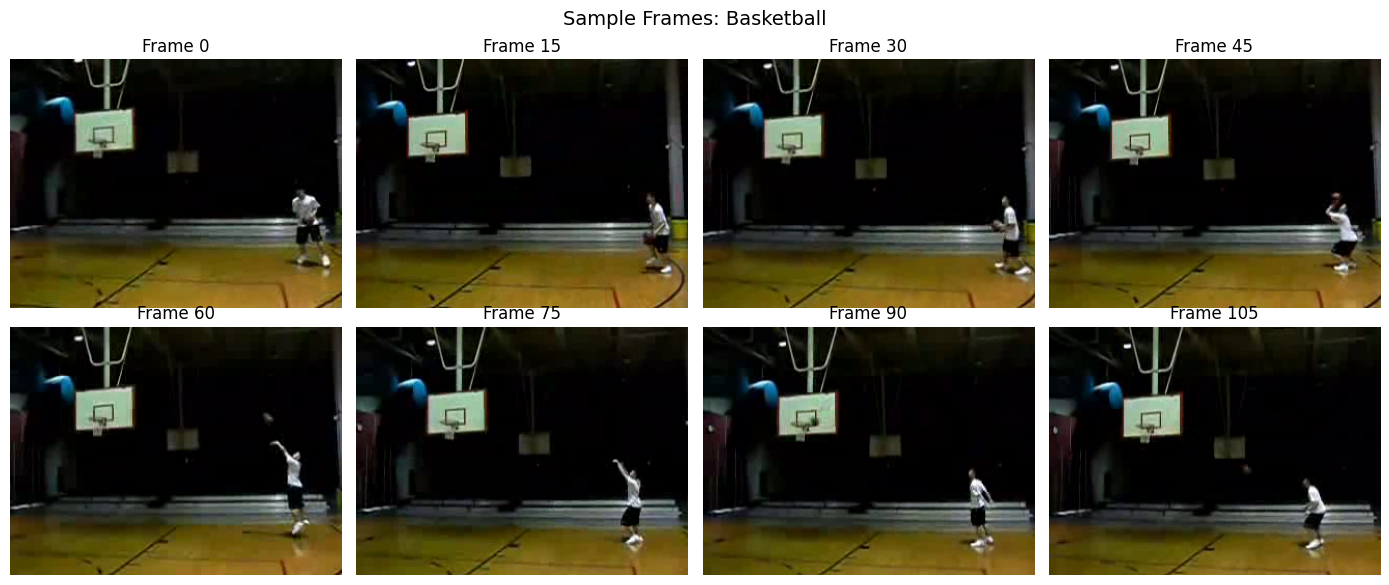

In [10]:
# Plot
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle(f"Sample Frames: {sample_class}", fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(frames[i])
    ax.set_title(f"Frame {i * 15}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Concept First — What Are We Actually Doing?

Raw Video (v_Basketball_g01_c01.avi)
         
         
         ↓
    
    
    OpenCV reads it
    
         
         ↓


Video has ~150 frames total

         
         ↓


We DON'T take all 150 (too much, redundant)

         
         ↓


We uniformly sample exactly 16 
frames

         
         ↓


Output → array of shape (16, 224, 224, 3)

         
         ↓


This is ONE training sample for our model


In [11]:
def extract_frames(video_path, num_frames=16, img_size=224):
    """
    Takes a raw video file and returns exactly num_frames
    uniformly sampled frames resized to img_size x img_size
    
    Args:
        video_path : full path to .avi video file
        num_frames : how many frames to extract (default 16)
        img_size   : resize each frame to this size (default 224)
    
    Returns:
        numpy array of shape (num_frames, img_size, img_size, 3)
        or None if video can't be read
    """
    
    cap = cv2.VideoCapture(video_path)
    
    # How many frames does this video have?
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # If video is broken or empty → skip it
    if total_frames == 0:
        cap.release()
        return None
    
    # Pick 16 evenly spaced frame positions
    # e.g. video has 150 frames → picks [0, 9, 18, 27, ...]
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        
        # Jump directly to that frame position
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        
        if ret:
            # Resize to 224x224 (ResNet50 input size)
            frame = cv2.resize(frame, (img_size, img_size))
            
            # Convert BGR → RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Normalize pixel values 0-255 → 0.0-1.0
            frame = frame / 255.0
            
            frames.append(frame)
        else:
            # If a frame fails to read → add blank frame
            frames.append(np.zeros((img_size, img_size, 3)))
    
    cap.release()
    
    # Return as numpy array → shape: (16, 224, 224, 3)
    return np.array(frames, dtype=np.float32)

In [12]:
# — Test It On ONE Video First

# Test on our sample video from Phase 1
test_frames = extract_frames(sample_video_path)

print(f"Output shape : {test_frames.shape}")
print(f"Min value    : {test_frames.min():.2f}")
print(f"Max value    : {test_frames.max():.2f}")
print(f"Data type    : {test_frames.dtype}")

Output shape : (16, 224, 224, 3)
Min value    : 0.00
Max value    : 1.00
Data type    : float32


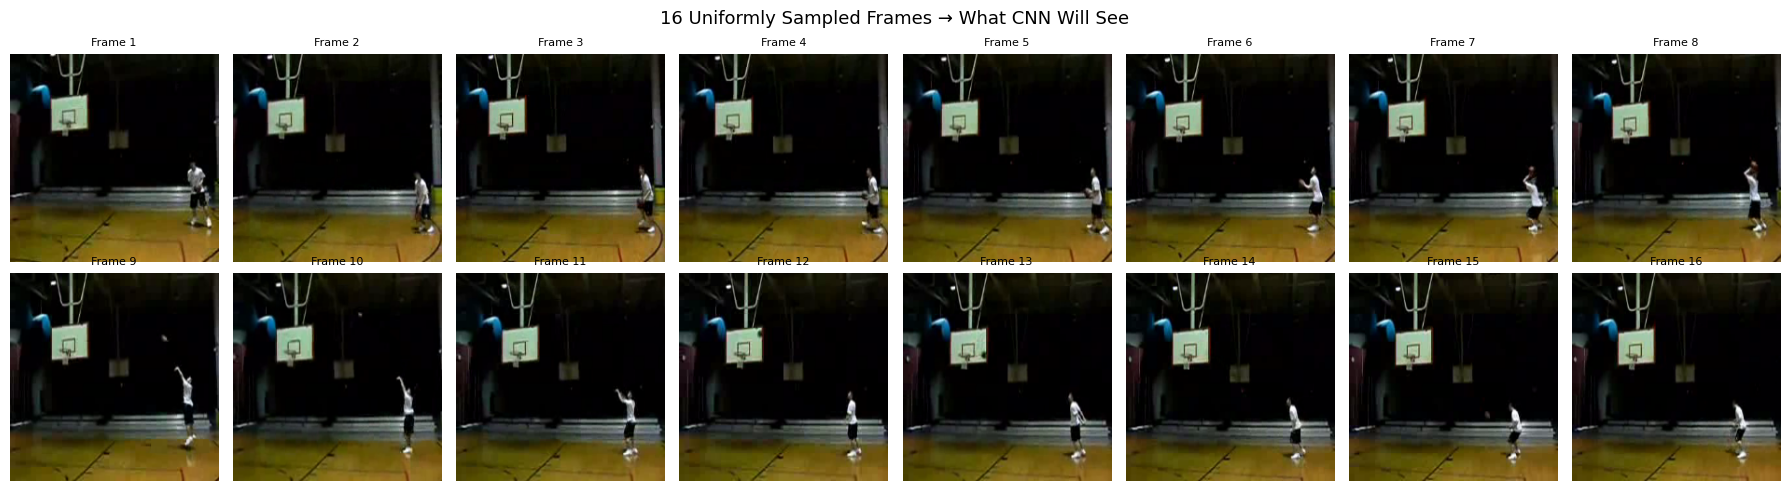

In [13]:
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle("16 Uniformly Sampled Frames → What CNN Will See", fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.imshow(test_frames[i])
    ax.set_title(f"Frame {i+1}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

**THE REASONNING**
: we do not use flow_from_directory because here we are not working directly on images instead we are using video fro that we will use this time **TRAIN_TEST_SPLIT**

# PHASE 2 + 3 + 4 — Frame Extraction + CNN Features + Split

**Why combined?** Storing raw frames crashes Kaggle RAM (23 GB!).
We extract frames → pass immediately to ResNet50 → store only features (340 MB ✅)

```
Old (RAM crash ❌): Video → Frames → Store ALL → CNN → LSTM
New (correct ✅) : Video → Frames → CNN → Store features only → LSTM
```

In [14]:
# ── STEP 1: Load Pretrained ResNet50 ──────────────────────────────
# include_top=False  → removes final Dense(1000) classification layer
# trainable=False     → freeze weights, reuse ImageNet knowledge
# GlobalAveragePooling2D → converts (7,7,2048) → flat (2048,)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

base_cnn = ResNet50(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)
base_cnn.trainable = True
for layer in base_cnn.layers[:-20]:  # freeze all except last 20
    layer.trainable = False   # freeze — we only use it as a feature extractor

cnn_input  = Input(shape=(224, 224, 3))
cnn_out    = base_cnn(cnn_input, training=False)
cnn_out    = GlobalAveragePooling2D()(cnn_out)  # (7,7,2048) → (2048,)
cnn_model  = Model(cnn_input, cnn_out, name='CNN_FeatureExtractor')

print('✅ ResNet50 loaded and frozen')
print(f'Output feature size per frame: 2048')
print(f'Trainable params: {cnn_model.count_params():,}')  # should be 0


I0000 00:00:1781728579.829076      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781728579.834940      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ ResNet50 loaded and frozen
Output feature size per frame: 2048
Trainable params: 23,587,712


In [15]:
# ── STEP 2: Combined Frame Extraction + CNN Feature Function ───────
# This function NEVER stores raw frames in RAM
# Input  : path to one .avi video
# Output : numpy array of shape (16, 2048) — CNN features only

def extract_frames_and_features(video_path, cnn_model, num_frames=16, img_size=224):
    cap          = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return None

    # Uniformly sample frame positions across the full video
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (img_size, img_size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # BGR → RGB
            frame = frame / 255.0                           # normalize 0-1
            frames.append(frame)
        else:
            frames.append(np.zeros((img_size, img_size, 3)))  # blank if broken

    cap.release()

    # Convert to array → (16, 224, 224, 3)
    frames = np.array(frames, dtype=np.float32)

    # Pass through CNN immediately → (16, 2048)
    # Raw frames are discarded here — RAM stays safe ✅
    features = cnn_model.predict(frames, verbose=0)

    return features  # shape: (16, 2048)


# Quick test on one video before processing everything
test_feat = extract_frames_and_features(sample_video_path, cnn_model)
print(f'✅ Test output shape : {test_feat.shape}')  # should be (16, 2048)
print(f'Min: {test_feat.min():.4f}  Max: {test_feat.max():.4f}')


I0000 00:00:1781728585.527693      90 service.cc:152] XLA service 0x7a76f80ca5f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781728585.527738      90 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781728585.527743      90 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781728586.426100      90 cuda_dnn.cc:529] Loaded cuDNN version 91002


✅ Test output shape : (16, 2048)
Min: 0.0000  Max: 12.3789


I0000 00:00:1781728590.418851      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [16]:
# ── STEP 3: Process ALL Videos → Store Only CNN Features ───────────
NUM_FRAMES  = 16
IMG_SIZE    = 224

all_features = []   # each entry: (16, 2048)
all_labels   = []   # each entry: int class index

print('Extracting CNN features from all videos...\n')

for class_name in SELECTED_CLASSES:
    class_folder = os.path.join(DATA_PATH, class_name)
    video_files  = os.listdir(class_folder)
    label        = class_to_idx[class_name]

    print(f'Processing: {class_name} ({len(video_files)} videos)')

    for video_file in tqdm(video_files):
        video_path = os.path.join(class_folder, video_file)
        features   = extract_frames_and_features(video_path, cnn_model,
                                                  NUM_FRAMES, IMG_SIZE)
        if features is not None and len(features) == NUM_FRAMES:
            all_features.append(features)
            all_labels.append(label)

# Convert to numpy
X = np.array(all_features, dtype=np.float32)  # (N, 16, 2048)
y = np.array(all_labels,   dtype=np.int32)     # (N,)

print(f'\n✅ Extraction Complete!')
print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}')
print(f'Memory usage : {X.nbytes / 1e6:.1f} MB')  # ~340 MB only!


Extracting CNN features from all videos...

Processing: Basketball (134 videos)


100%|██████████| 134/134 [00:27<00:00,  4.79it/s]


Processing: TennisSwing (166 videos)


100%|██████████| 166/166 [00:35<00:00,  4.69it/s]


Processing: GolfSwing (139 videos)


...

Processing: IceDancing (158 videos)


100%|██████████| 158/158 [01:07<00:00,  2.34it/s]


Processing: PlayingGuitar (160 videos)


100%|██████████| 160/160 [00:41<00:00,  3.84it/s]


✅ Extraction Complete!
X shape      : (2719, 16, 2048)
y shape      : (2719,)
Memory usage : 356.4 MB


# PHASE 3 — Train / Validation / Test Split

**Why stratify=y?** Ensures each split has equal representation of all 20 classes.

**Split ratio:** 80% train → 10% val → 10% test


In [17]:
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X shape : (2719, 16, 2048)
y shape : (2719,)


In [18]:
# ── STEP 4: Split Data ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = len(SELECTED_CLASSES)

# 80% train / 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y        # equal class distribution ✅
)

# Split temp → 50% val / 50% test  (each = 10% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size    = 0.5,     # ← 0.5 not 0.2! splits temp 50/50
    random_state = 42,
    stratify     = y_temp   # ← stratify not startify!
)

# One-hot encode labels (required for categorical_crossentropy)
y_train = to_categorical(y_train, NUM_CLASSES)
y_val   = to_categorical(y_val,   NUM_CLASSES)
y_test  = to_categorical(y_test,  NUM_CLASSES)

print('Split summary:')
print(f'  X_train : {X_train.shape}  y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape}    y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}   y_test  : {y_test.shape}')


Split summary:
  X_train : (2175, 16, 2048)  y_train : (2175, 20)
  X_val   : (272, 16, 2048)    y_val   : (272, 20)
  X_test  : (272, 16, 2048)   y_test  : (272, 20)


In [19]:
# ── STEP 5: Save to Disk ────────────────────────────────────────────
# IMPORTANT: Always save! If Kaggle session crashes you won't redo 2 hours of work

np.save('X_train.npy', X_train)
np.save('X_val.npy',   X_val)
np.save('X_test.npy',  X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
np.save('y_test.npy',  y_test)

# Verify all saved correctly
saved_files = ['X_train.npy','X_val.npy','X_test.npy',
               'y_train.npy','y_val.npy','y_test.npy']
for f in saved_files:
    size = os.path.getsize(f) / 1e6
    print(f'✅ {f:20s} → {size:.1f} MB')

print('\n✅ All files saved! Phase 2+3+4 Complete!')


✅ X_train.npy          → 285.1 MB
✅ X_val.npy            → 35.7 MB
✅ X_test.npy           → 35.7 MB
✅ y_train.npy          → 0.3 MB
✅ y_val.npy            → 0.0 MB
✅ y_test.npy           → 0.0 MB

✅ All files saved! Phase 2+3+4 Complete!


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                      BatchNormalization)

# ── CONFIG ──────────────────────────────────────────
NUM_FRAMES  = 16
FEATURE_DIM = 2048   # ResNet50 output size
NUM_CLASSES = len(SELECTED_CLASSES)

# ── BUILD MODEL ─────────────────────────────────────
model = Sequential([

    # LSTM Layer 1
    # input_shape = (16 frames, 2048 features per frame)
    # return_sequences=True → passes full sequence to next LSTM
    LSTM(256,
         input_shape      = (NUM_FRAMES, FEATURE_DIM),
         return_sequences = True),

    # Dropout → randomly turns off 30% of neurons
    # Why? → prevents memorizing training data (overfitting)
    Dropout(0.3),

    # LSTM Layer 2
    # return_sequences=False → only returns FINAL hidden state
    # Why? → we only need one summary vector for classification
    LSTM(128,
         return_sequences = False),

    Dropout(0.3),

    # BatchNormalization → stabilizes training
    # normalizes outputs so gradients flow smoothly
    BatchNormalization(),

    # Dense Layer → compress 128 → 64
    Dense(64, activation='relu'),

    Dropout(0.2),

    # Final Output Layer
    # 20 neurons = 20 classes
    # softmax → converts raw scores to probabilities (sum = 1.0)
    Dense(NUM_CLASSES, activation='softmax')

], name="VideoActionRecognition")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "VideoActionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 256)        │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,567,508 (9.79 MB)

 Trainable params: 2,567,252 (9.79 MB)

 Non-trainable params: 256 (1.00 KB)

In [21]:
# Visualize what each layer does to your data shape
shapes = [
    ("Input (CNN features)",   "(batch, 16, 2048)"),
    ("LSTM Layer 1",           "(batch, 16, 256) ← sequence kept"),
    ("Dropout 0.3",            "(batch, 16, 256)"),
    ("LSTM Layer 2",           "(batch, 128)     ← sequence collapsed"),
    ("Dropout 0.3",            "(batch, 128)"),
    ("BatchNormalization",     "(batch, 128)"),
    ("Dense 64 relu",          "(batch, 64)"),
    ("Dropout 0.2",            "(batch, 64)"),
    ("Dense 20 softmax",       "(batch, 20)      ← 20 class scores"),
]

print("Data shape through each layer:\n")
for name, shape in shapes:
    print(f"  {name:<30} → {shape}")

Data shape through each layer:

  Input (CNN features)           → (batch, 16, 2048)
  LSTM Layer 1                   → (batch, 16, 256) ← sequence kept
  Dropout 0.3                    → (batch, 16, 256)
  LSTM Layer 2                   → (batch, 128)     ← sequence collapsed
  Dropout 0.3                    → (batch, 128)
  BatchNormalization             → (batch, 128)
  Dense 64 relu                  → (batch, 64)
  Dropout 0.2                    → (batch, 64)
  Dense 20 softmax               → (batch, 20)      ← 20 class scores


In [22]:
model.compile(
    # Adam = best general purpose optimizer
    # lr=0.001 = learning rate (how big each update step is)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),

    # categorical_crossentropy = standard loss for multi-class
    # requires one-hot labels (which we already have ✅)
    loss = 'categorical_crossentropy',

    # metrics we want to track during training
    metrics = ['accuracy']
)

print("✅ Model compiled!")
print(f"Total trainable params: {model.count_params():,}")

✅ Model compiled!
Total trainable params: 2,567,508


In [23]:
from tensorflow.keras.callbacks import (ModelCheckpoint,
                                         EarlyStopping,
                                         ReduceLROnPlateau)

callbacks = [

    # Save best model automatically
    # monitors val_accuracy → saves whenever it improves
    ModelCheckpoint(
        filepath        = 'best_modelllll.keras',
        monitor         = 'val_accuracy',
        save_best_only  = True,
        verbose         = 1
    ),

    # Stop training if model stops improving
    # patience=7 → wait 7 epochs before stopping
    # Why? → saves GPU hours if model plateaus early
    EarlyStopping(
        monitor   = 'val_accuracy',
        patience  = 7,
        verbose   = 1,
        restore_best_weights = True  # go back to best weights
    ),

    # Reduce learning rate when stuck
    # If val_loss doesn't improve for 4 epochs → lr = lr * 0.5
    # Why? → smaller steps help escape plateaus
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 4,
        verbose  = 1,
        min_lr   = 1e-6
    )
]

print("✅ Callbacks ready!")
print("  → ModelCheckpoint : saves best model to best_model.keras")
print("  → EarlyStopping   : stops if no improvement for 7 epochs")
print("  → ReduceLROnPlateau: halves lr if stuck for 4 epochs")

✅ Callbacks ready!
  → ModelCheckpoint : saves best model to best_model.keras
  → EarlyStopping   : stops if no improvement for 7 epochs
  → ReduceLROnPlateau: halves lr if stuck for 4 epochs


In [24]:
history = model.fit(
    X_train, y_train,

    # batch_size=32 → process 32 videos at once
    # smaller = more stable but slower
    # larger  = faster but needs more RAM
    batch_size = 32,

    # epochs=50 but EarlyStopping will likely stop it earlier
    epochs     = 100,

    # validation data → check performance after each epoch
    validation_data = (X_val, y_val),

    callbacks  = callbacks,
    verbose    = 1
)

print("\n✅ Training Complete!")

Epoch 1/100
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0538 - loss: 3.5568
Epoch 1: val_accuracy improved from -inf to 0.06250, saving model to best_modelllll.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.0541 - loss: 3.5544 - val_accuracy: 0.0625 - val_loss: 2.9936 - learning_rate: 1.0000e-04
Epoch 2/100
66/68 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0655 - loss: 3.3424
Epoch 2: val_accuracy improved from 0.06250 to 0.08088, saving model to best_modelllll.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.0655 - loss: 3.3396 - val_accuracy: 0.0809 - val_loss: 2.9488 - learning_rate: 1.0000e-04
Epoch 3/100
66/68 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1097 - loss: 3.1362
Epoch 3: val_accuracy improved from 0.08088 to 0.14706, saving model to best_modelllll.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1098 - loss: 3.1345 - val_accuracy: 0.1471 - val_loss: 2.8759 - learning_rate: 1.0000e-04
Epoch 4/100
64/68 ━━━━━━━━━━━━━━━━

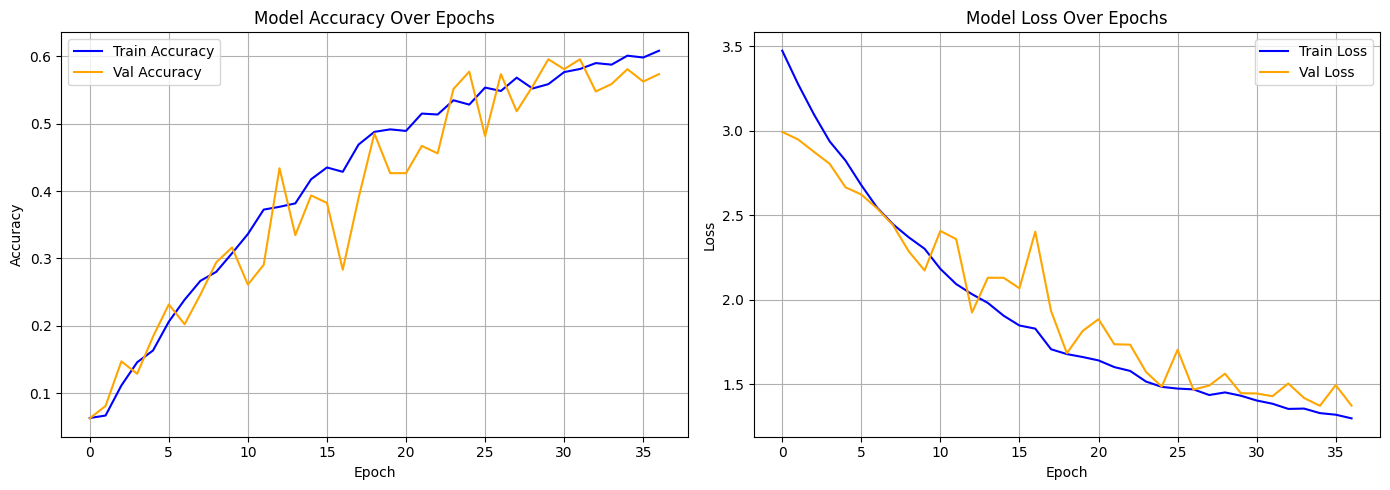

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Plot ──
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# ── Loss Plot ──
axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Load best model first (most accurate version)
from tensorflow.keras.models import load_model
best_model = load_model('/kaggle/working/best_modelllll.keras')

# Evaluate on unseen test data
test_loss, test_accuracy = best_model.evaluate(
    X_test, y_test, verbose=1
)

print(f"\n{'='*40}")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"{'='*40}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5439 - loss: 1.4400  

Test Loss     : 1.4580
Test Accuracy : 53.68%


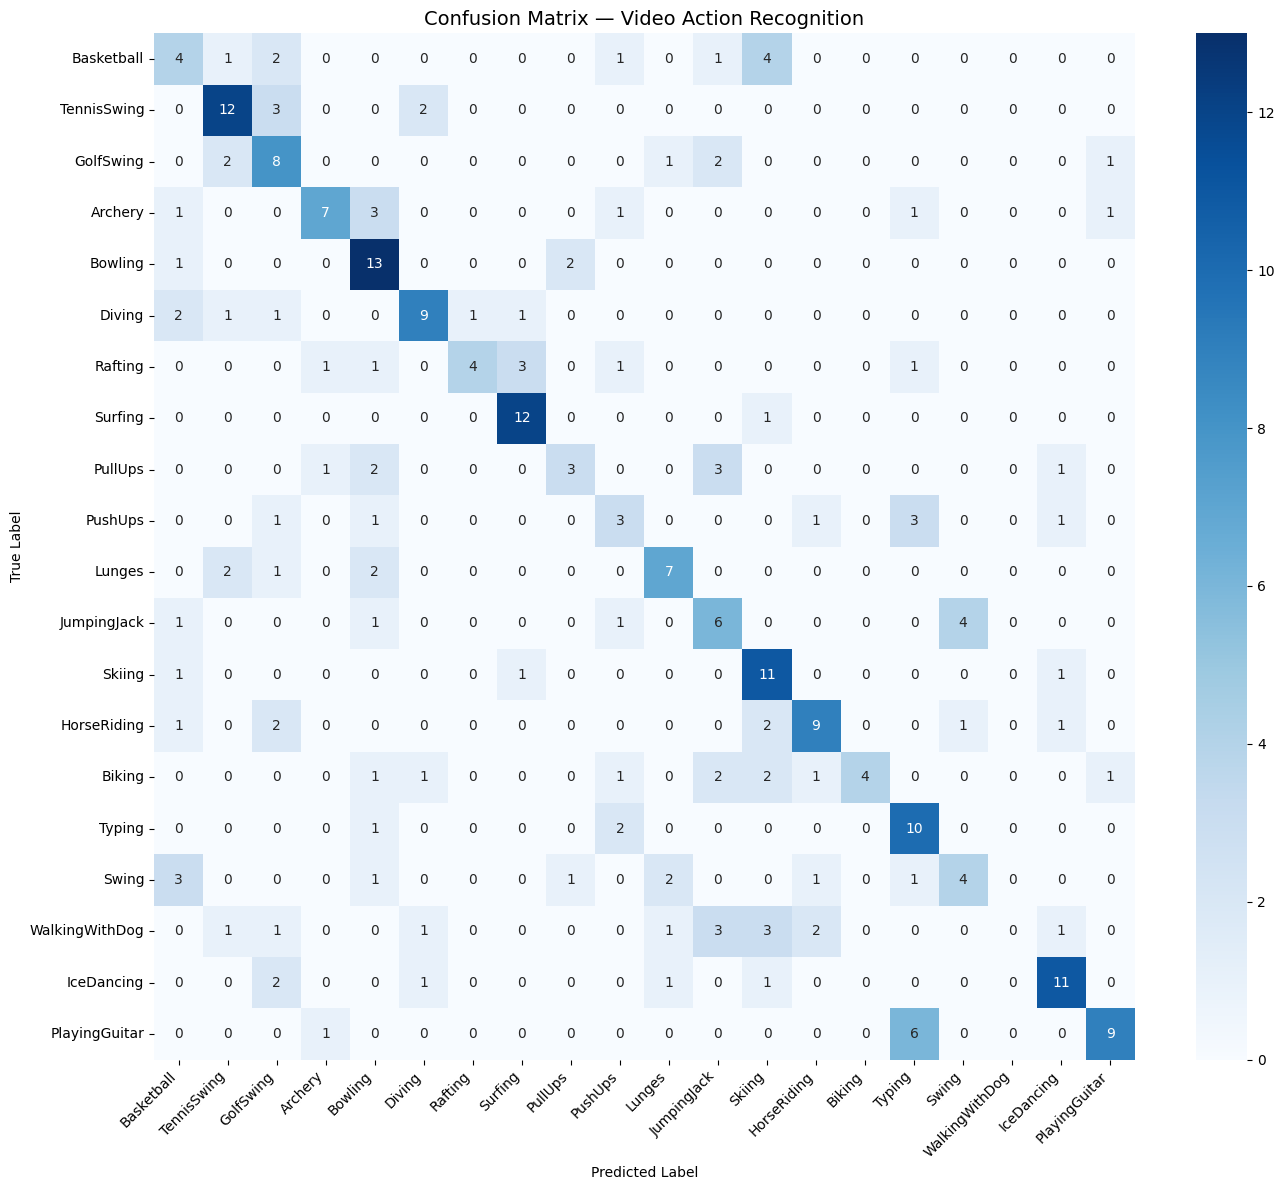

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)  # highest prob class
y_true       = np.argmax(y_test,       axis=1)  # true class

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels = SELECTED_CLASSES,
    yticklabels = SELECTED_CLASSES
)
plt.title('Confusion Matrix — Video Action Recognition', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
# Detailed report for every class
report = classification_report(
    y_true, y_pred,
    target_names = SELECTED_CLASSES
)
print("Per-Class Performance:\n")
print(report)

Per-Class Performance:

                precision    recall  f1-score   support

    Basketball       0.29      0.31      0.30        13
   TennisSwing       0.63      0.71      0.67        17
     GolfSwing       0.38      0.57      0.46        14
       Archery       0.70      0.50      0.58        14
       Bowling       0.50      0.81      0.62        16
        Diving       0.64      0.60      0.62        15
       Rafting       0.80      0.36      0.50        11
       Surfing       0.71      0.92      0.80        13
       PullUps       0.50      0.30      0.38        10
       PushUps       0.30      0.30      0.30        10
        Lunges       0.58      0.58      0.58        12
   JumpingJack       0.35      0.46      0.40        13
        Skiing       0.46      0.79      0.58        14
   HorseRiding       0.64      0.56      0.60        16
        Biking       1.00      0.31      0.47        13
        Typing       0.45      0.77      0.57        13
         Swing       0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualize Real Predictions
Show actual video frames with predicted vs true label:


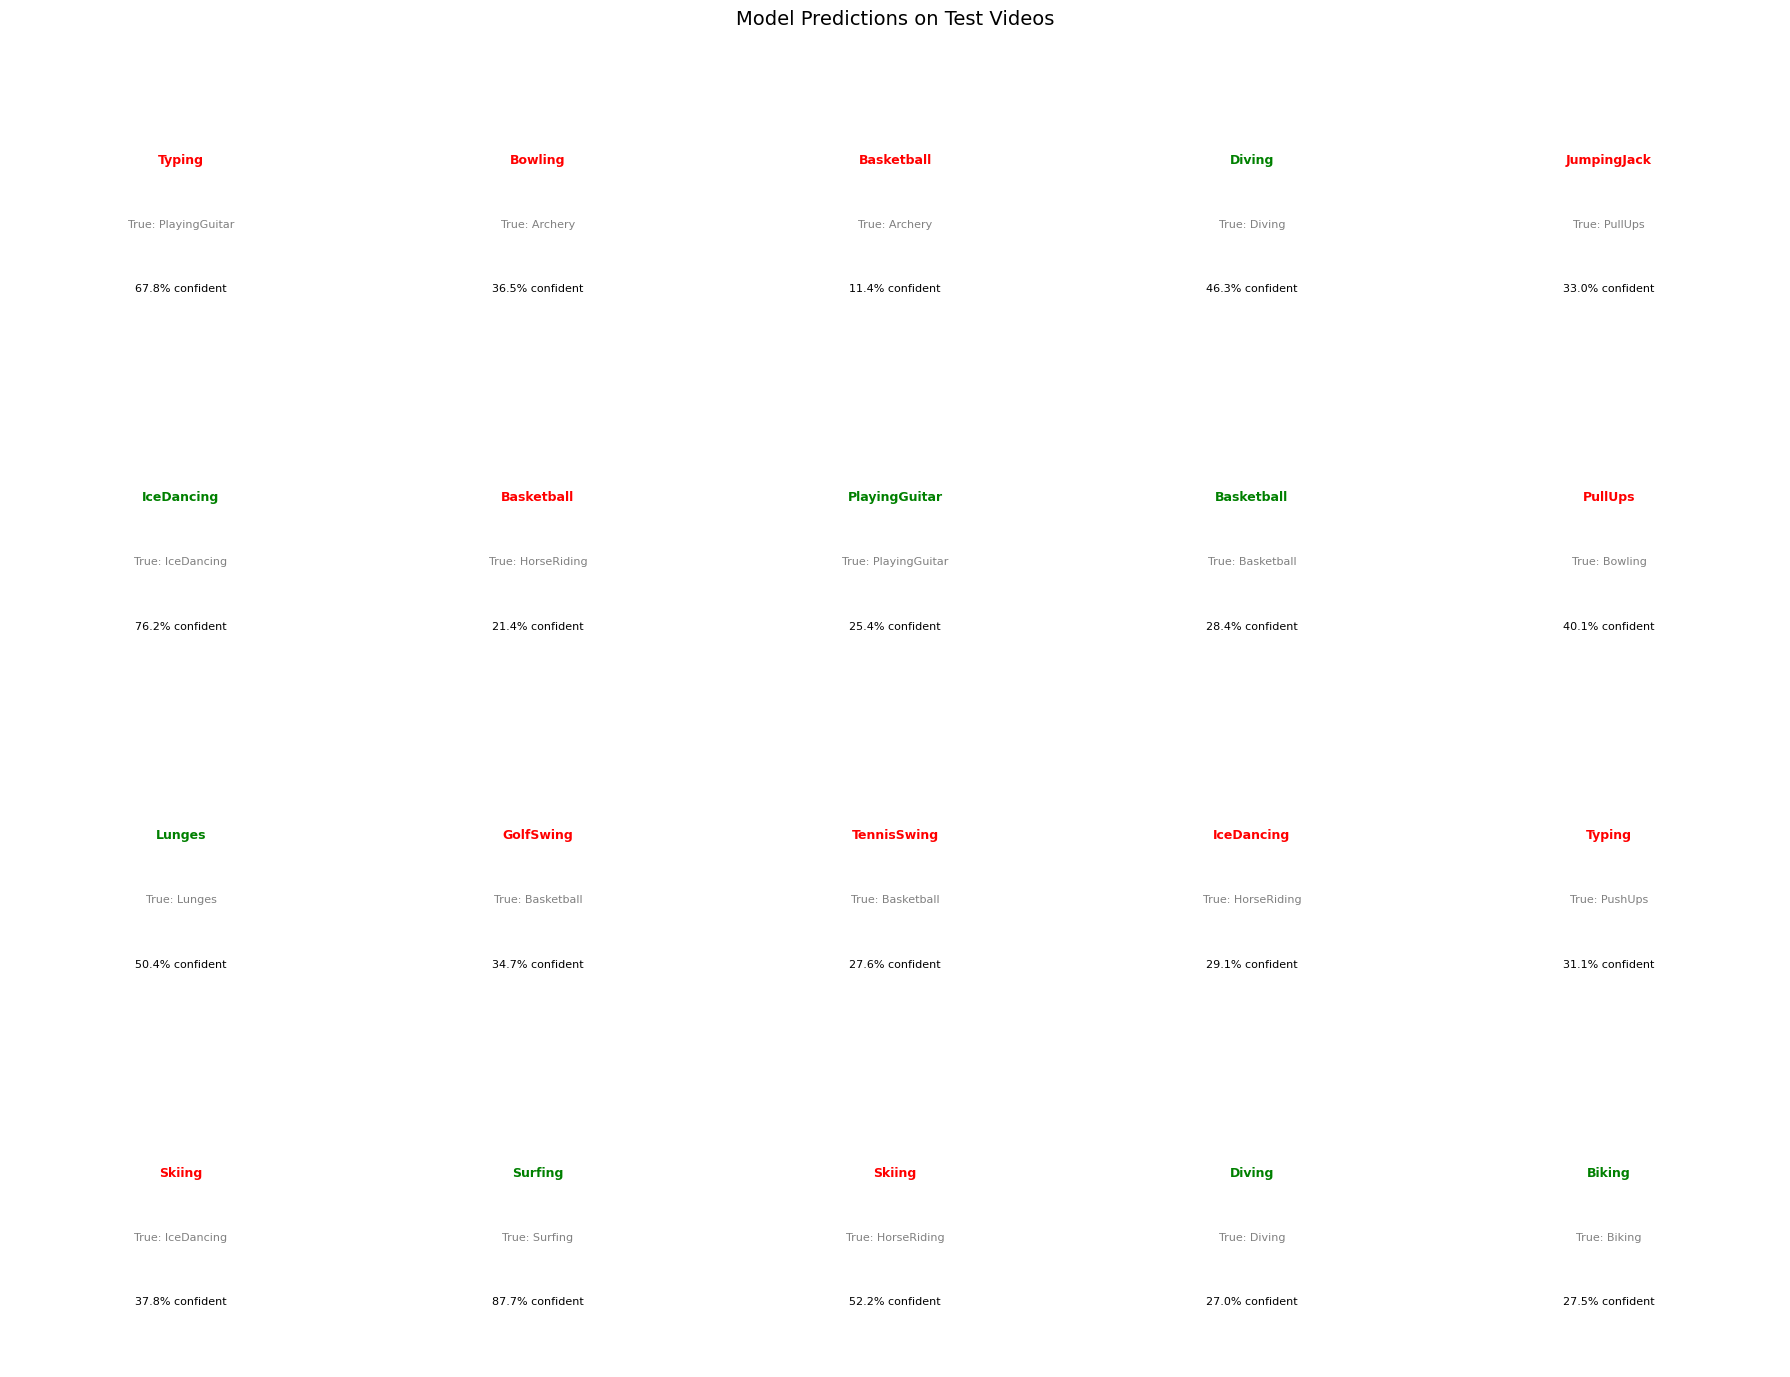

In [29]:
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('Model Predictions on Test Videos', fontsize=14)

# Pick 20 random test samples
sample_indices = np.random.choice(len(X_test), 20, replace=False)

for i, idx in enumerate(sample_indices):
    ax = axes[i // 5][i % 5]

    # Get middle frame of the video (frame 8 out of 16)
    # X_test has CNN features not raw frames so we reload from X
    true_label = SELECTED_CLASSES[y_true[idx]]
    pred_label = SELECTED_CLASSES[y_pred[idx]]
    confidence = y_pred_probs[idx][y_pred[idx]] * 100

    # Color green if correct, red if wrong
    color = 'green' if true_label == pred_label else 'red'

    ax.set_facecolor('#e8f5e9' if true_label == pred_label else '#ffebee')
    ax.text(0.5, 0.6, pred_label,
            ha='center', va='center',
            fontsize=9, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.4, f'True: {true_label}',
            ha='center', va='center',
            fontsize=8, color='gray',
            transform=ax.transAxes)
    ax.text(0.5, 0.2, f'{confidence:.1f}% confident',
            ha='center', va='center',
            fontsize=8, color='black',
            transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [30]:
# For each sample check if true label is in top 3 predictions
top3_correct = 0

for i in range(len(y_true)):
    top3_preds = np.argsort(y_pred_probs[i])[-3:]  # top 3 indices
    if y_true[i] in top3_preds:
        top3_correct += 1

top3_accuracy = top3_correct / len(y_true) * 100

print(f"Top-1 Accuracy : {test_accuracy*100:.2f}%")
print(f"Top-3 Accuracy : {top3_accuracy:.2f}%")

Top-1 Accuracy : 53.68%
Top-3 Accuracy : 79.78%


In [31]:
# Step 1 → Backup current model
model.save('model_66percent.keras')
print("✅ Current 66% model backed up!")

# Step 2 → Recompile with lower learning rate
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Step 3 → Continue training (callbacks already save best)
history2 = model.fit(
    X_train, y_train,
    batch_size      = 32,
    epochs          = 30,
    validation_data = (X_val, y_val),
    callbacks       = callbacks  # ← ModelCheckpoint inside this
)

# Step 4 → Save final result separately
model.save('model_optionA_final.keras')
print("✅ Option A final model saved!")

✅ Current 66% model backed up!
Epoch 1/30
65/68 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5280 - loss: 1.5275
Epoch 1: val_accuracy did not improve from 0.59559
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5282 - loss: 1.5268 - val_accuracy: 0.4596 - val_loss: 1.8797 - learning_rate: 1.0000e-04
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5524 - loss: 1.4379
Epoch 2: val_accuracy did not improve from 0.59559
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5522 - loss: 1.4387 - val_accuracy: 0.4926 - val_loss: 1.7569 - learning_rate: 1.0000e-04
Epoch 3/30
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5488 - loss: 1.4409
Epoch 3: val_accuracy did not improve from 0.59559
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5492 - loss: 1.4406 - val_accuracy: 0.4596 - val_loss: 1.6870 - learning_rate: 1.0000e-04
Epoch 4/30
64/68 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5691 - loss: 1.3608
Epoch 4: val_accuracy did not improve from 0

In [32]:
# For each sample check if true label is in top 3 predictions
top3_correct = 0

for i in range(len(y_true)):
    top3_preds = np.argsort(y_pred_probs[i])[-3:]  # top 3 indices
    if y_true[i] in top3_preds:
        top3_correct += 1

top3_accuracy = top3_correct / len(y_true) * 100

print(f"Top-1 Accuracy : {test_accuracy*100:.2f}%")
print(f"Top-3 Accuracy : {top3_accuracy:.2f}%")

Top-1 Accuracy : 53.68%
Top-3 Accuracy : 79.78%
